# Лабораторная работа №3 — Оптимизация гиперпараметров

#### Работу выполнил студент 303 группы Ефимов Сергей

### Тема:
##### GridSearchCV, RandomizedSearchCV, Optuna.

### Датасет:
##### Любой из первых двух (по выбору студента).

### Цель работы:
#### Научиться подбирать оптимальные гиперпараметры для моделей машинного обучения и анализировать влияние параметров на качество модели.

### Задачи

1. Выбрать модель из прошлых двух лабораторных работ, приоритетнее модель, с высоким качеством на test выборке (например, градиентный бустинг в задаче предсказания оттока из л/р 2).
2. Определить диапазон гиперпараметров для подбора.
3. Использовать один из методов оптимизации:\
    a. GridSearchCV — полный перебор;\
    b. RandomizedSearchCV — случайный поиск;\
    c. (дополнительно) Optuna — байесовская оптимизация.
4. Провести кросс-валидацию до и после подбора гиперпараметров на одинаковых folds (например, 5-fold CV).
5. Сравнить качество до и после подбора гиперпараметров.
6. Визуализировать результаты (например, как изменилось распределение важности признаков, ROC-AUC).
7. Сделать вывод о влиянии гиперпараметров.

### Результат модели до методов оптимизации

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import roc_curve, roc_auc_score

df = pd.read_csv('data/Telco-Customer-Churn.xls')

df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

df = df.dropna(subset=['TotalCharges'])

multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

df = df.drop('customerID', axis=1)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols] = scaler.fit_transform(df[num_cols])

X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

from xgboost import XGBClassifier

xgb = XGBClassifier()

xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

importances_before = xgb.feature_importances_

y_proba_before = xgb.predict_proba(X_test)[:, 1]
auc_before = roc_auc_score(y_test, y_proba_before)

cv = KFold(n_splits=5, shuffle=True)

scores_before = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='accuracy')
print("CV accuracy (before):", scores_before.mean())

CV accuracy (before): 0.7747555555555554


### GridSearchCV

In [2]:
from sklearn.model_selection import GridSearchCV

grid_params = {
    'n_estimators': [200, 400, 600],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier()

grid = GridSearchCV(
    estimator=xgb,
    param_grid=grid_params,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params (Grid):", grid.best_params_)
print("Best CV score (Grid):", grid.best_score_)


Best params (Grid): {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV score (Grid): 0.8007111111111112


### RandomizedSearchCV

In [3]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

rand_params = {
    'n_estimators': np.arange(200, 1501, 100),
    'max_depth': np.arange(2, 11),
    'learning_rate': np.logspace(-3, -1, 10),
    'subsample': np.linspace(0.5, 1.0, 6),
    'colsample_bytree': np.linspace(0.5, 1.0, 6),
    'gamma': np.arange(0, 11, 1),
    'min_child_weight': np.arange(1, 11)
}

rand = RandomizedSearchCV(
    xgb,
    param_distributions=rand_params,
    n_iter=50,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

rand.fit(X_train, y_train)

print("Best params (Randomized):", rand.best_params_)
print("Best CV score (Randomized):", rand.best_score_)


Best params (Randomized): {'subsample': 0.7, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 10, 'learning_rate': 0.05994842503189409, 'gamma': 10, 'colsample_bytree': 0.5}
Best CV score (Randomized): 0.7994666666666667


### Оценки моделей и сравнение

In [4]:
print("CV accuracy before:", scores_before.mean())

best_grid_model = grid.best_estimator_

scores_after_grid = cross_val_score(best_grid_model, X_train, y_train, cv=cv, scoring='accuracy')
print("CV accuracy after GridSearch:", scores_after_grid.mean())

best_rand_model = rand.best_estimator_

scores_after_rand = cross_val_score(best_rand_model, X_train, y_train, cv=cv, scoring='accuracy')
print("CV accuracy after RandomizedSearch:", scores_after_rand.mean())

print("Best CV accuracy: ", max(scores_after_grid.mean(), scores_after_rand.mean(), scores_before.mean()))


CV accuracy before: 0.7747555555555554
CV accuracy after GridSearch: 0.7987555555555556
CV accuracy after RandomizedSearch: 0.7975111111111111
Best CV accuracy:  0.7987555555555556


### Сравнение важности признаков

<Figure size 1000x600 with 0 Axes>

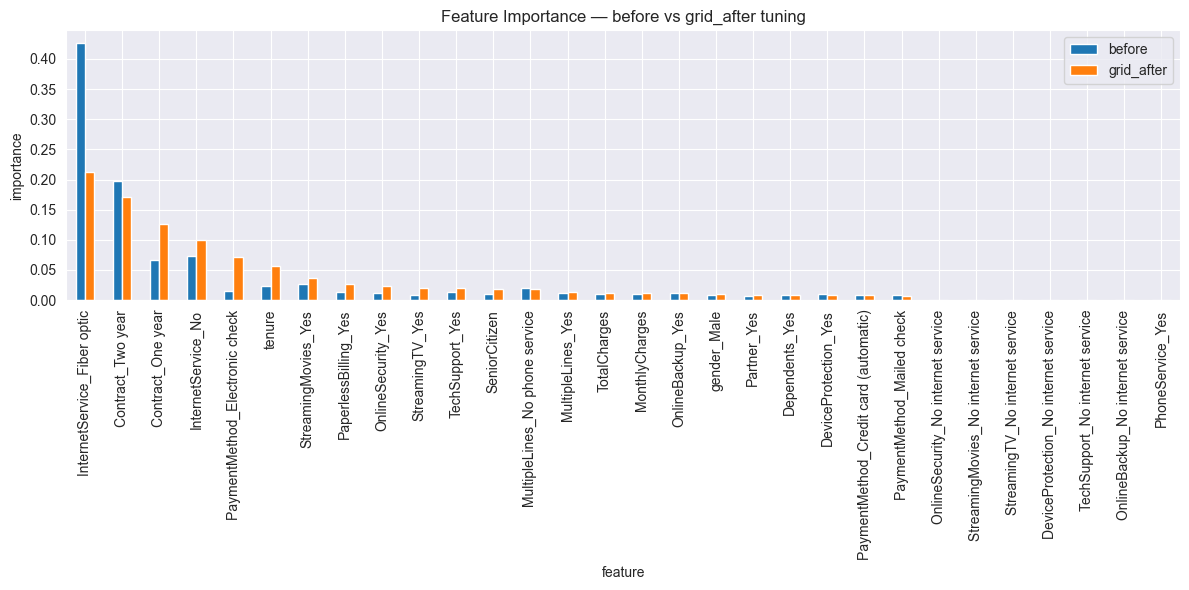

<Figure size 1000x600 with 0 Axes>

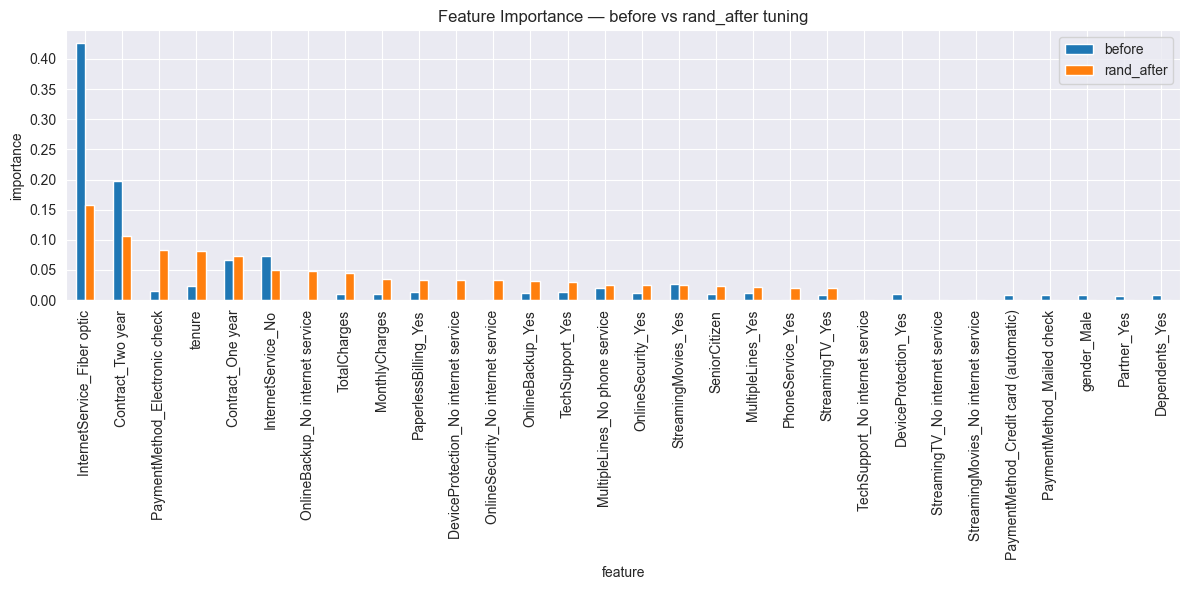

<Figure size 1000x600 with 0 Axes>

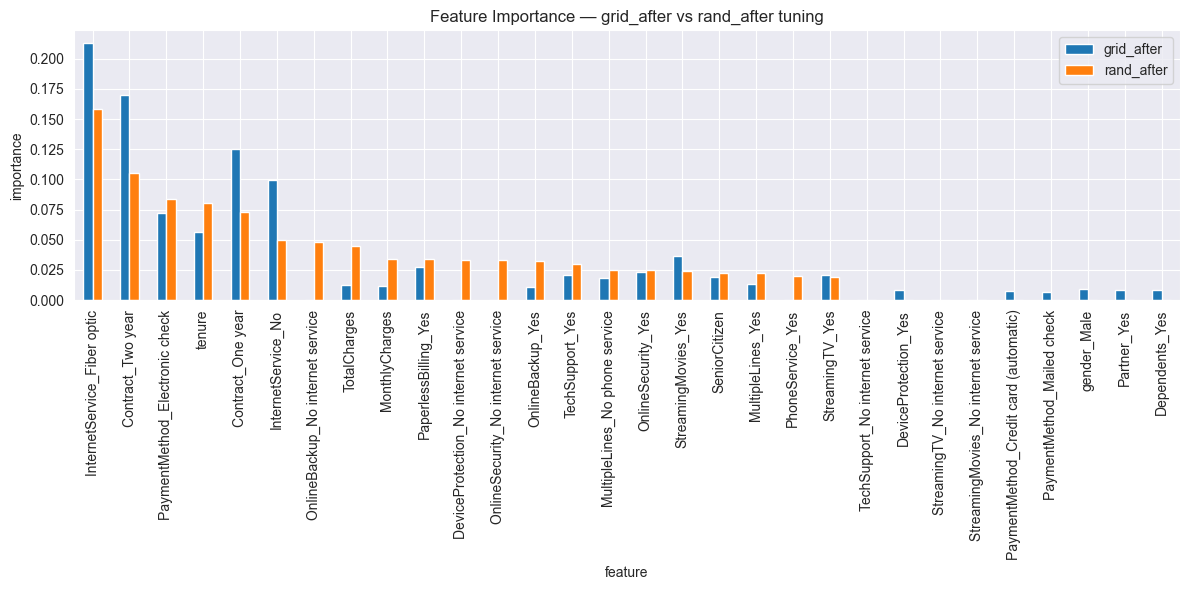

In [5]:
import matplotlib.pyplot as plt

importances_grid_after = best_grid_model.feature_importances_
importances_rand_after = best_rand_model.feature_importances_

feat_names = X_train.columns

df_imp = pd.DataFrame({
    "feature": feat_names,
    "before": importances_before,
    "grid_after": importances_grid_after
}).set_index("feature").sort_values("grid_after", ascending=False)

plt.figure(figsize=(10,6))
df_imp.plot(kind="bar", figsize=(12,6))
plt.title("Feature Importance — before vs grid_after tuning")
plt.ylabel("importance")
plt.tight_layout()
plt.show()

df_imp = pd.DataFrame({
    "feature": feat_names,
    "before": importances_before,
    "rand_after": importances_rand_after
}).set_index("feature").sort_values("rand_after", ascending=False)

plt.figure(figsize=(10,6))
df_imp.plot(kind="bar", figsize=(12,6))
plt.title("Feature Importance — before vs rand_after tuning")
plt.ylabel("importance")
plt.tight_layout()
plt.show()

df_imp = pd.DataFrame({
    "feature": feat_names,
    "grid_after": importances_grid_after,
    "rand_after": importances_rand_after
}).set_index("feature").sort_values("rand_after", ascending=False)

plt.figure(figsize=(10,6))
df_imp.plot(kind="bar", figsize=(12,6))
plt.title("Feature Importance — grid_after vs rand_after tuning")
plt.ylabel("importance")
plt.tight_layout()
plt.show()



AUC before: 0.8416183070957856
AUC grid: 0.8608098524105585
AUC rand: 0.8609923332177191


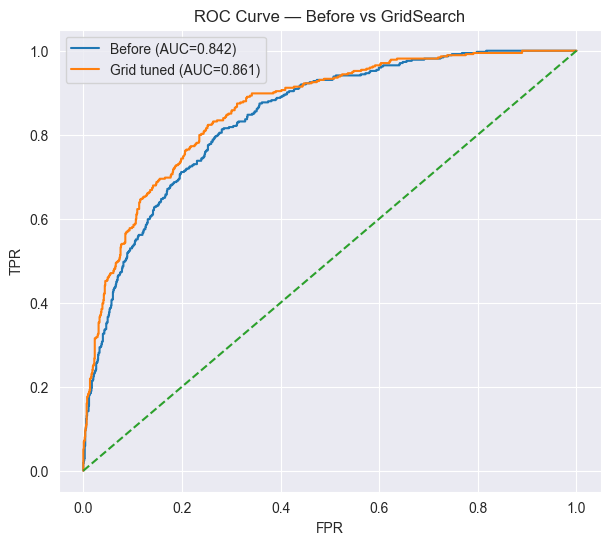

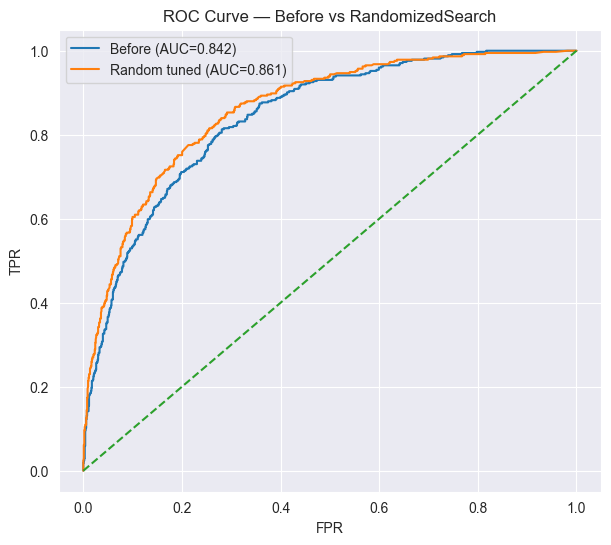

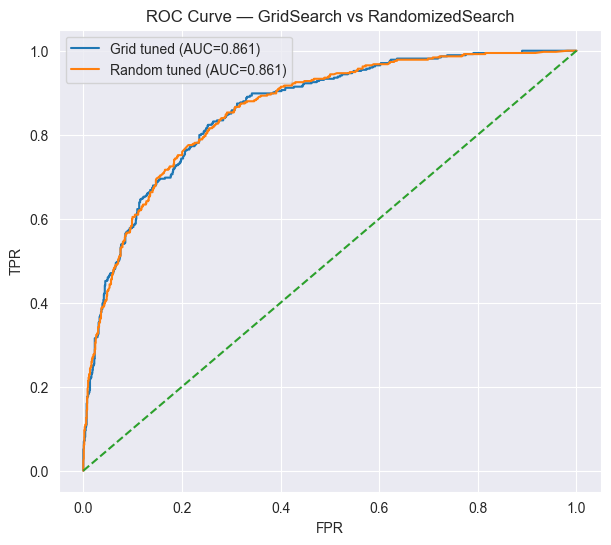

In [6]:
y_proba_grid = best_grid_model.predict_proba(X_test)[:, 1]
auc_grid = roc_auc_score(y_test, y_proba_grid)

y_proba_rand = best_rand_model.predict_proba(X_test)[:, 1]
auc_rand = roc_auc_score(y_test, y_proba_rand)

print("AUC before:", auc_before)
print("AUC grid:", auc_grid)
print("AUC rand:", auc_rand)

fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_before)
fpr_g, tpr_g, _ = roc_curve(y_test, y_proba_grid)

plt.figure(figsize=(7,6))
plt.plot(fpr_b, tpr_b, label=f"Before (AUC={auc_before:.3f})")
plt.plot(fpr_g, tpr_g, label=f"Grid tuned (AUC={auc_grid:.3f})")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve — Before vs GridSearch")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid(True)
plt.show()


fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_before)
fpr_r, tpr_r, _ = roc_curve(y_test, y_proba_rand)

plt.figure(figsize=(7,6))
plt.plot(fpr_b, tpr_b, label=f"Before (AUC={auc_before:.3f})")
plt.plot(fpr_r, tpr_r, label=f"Random tuned (AUC={auc_rand:.3f})")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve — Before vs RandomizedSearch")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid(True)
plt.show()


fpr_g, tpr_g, _ = roc_curve(y_test, y_proba_grid)
fpr_r, tpr_r, _ = roc_curve(y_test, y_proba_rand)

plt.figure(figsize=(7,6))
plt.plot(fpr_g, tpr_g, label=f"Grid tuned (AUC={auc_grid:.3f})")
plt.plot(fpr_r, tpr_r, label=f"Random tuned (AUC={auc_rand:.3f})")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve — GridSearch vs RandomizedSearch")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid(True)
plt.show()


### Выводы

Как можно увидеть на графиках, влияние гиперпараметров очевидно положительно влияет на метрики, следовательно и на качество модели.\
GridSearchCV и RandomizedSearchCV показывают себя примерно одинаково.\
Изменилось распределение параметров, причем параметры GridSearchCV и RandomizedSearchCV отличаются сильно меньше, чем параметры до их оптимизации и после.
